# Динамические точки останова (Dynamic breakpoints)

## Обзор (Review)

Мы обсудили причины для включения человека в цикл (human-in-the-loop):

1. **Согласование (Approval)** - Мы можем прервать агента, показать состояние пользователю и разрешить подтверждение действия
2. **Отладка (Debugging)** - Мы можем перемотать граф для воспроизведения или избежания проблем
3. **Редактирование (Editing)** - Возможность модификации состояния

Мы рассмотрели точки останова (breakpoints) как общий способ остановки графа на конкретных шагах, что реализует сценарии типа `Approval`.

Также мы показали, как редактировать состояние графа и добавлять обратную связь от человека.

## Цели (Goals)

Точки останова устанавливаются разработчиком на конкретные узлы (nodes) во время компиляции графа.

Но иногда полезно разрешить графу **прерываться динамически**!

Это внутренняя точка останова (internal breakpoint), [реализуемая через `NodeInterrupt`](https://langchain-ai.github.io/langgraph/how-tos/human_in_the_loop/dynamic_breakpoints/#run-the-graph-with-dynamic-interrupt).

Преимущества такого подхода:

1. Условное прерывание (на основе логики, определённой разработчиком внутри узла)
2. Возможность объяснить причину прерывания пользователю (передавая любые данные через `NodeInterrupt`)

Создадим граф с вызовом `NodeInterrupt` на основе длины ввода.

------------------------------------------------------------------------------------------------

In [1]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage
from langchain_gigachat import GigaChat

import os
api_key = os.getenv("GIGA_API_KEY")

llm = model = GigaChat(
    credentials = api_key,
    verify_ssl_certs=False,
    scope = 'GIGACHAT_API_CORP',
    temperature=0.0,
    profanity_check = False,
    model="GigaChat",
)

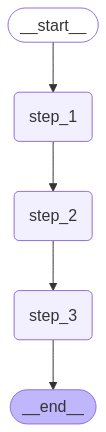

In [2]:
from IPython.display import Image, display

from typing_extensions import TypedDict
from langgraph.checkpoint.memory import MemorySaver
from langgraph.errors import NodeInterrupt
from langgraph.graph import START, END, StateGraph

class State(TypedDict):
    input: str

def step_1(state: State) -> State:
    print("---Шаг 1---")
    return state

def step_2(state: State) -> State:
    # Вызываем NodeInterrupt если длина ввода больше 5 символов
    if len(state['input']) > 5:
        raise NodeInterrupt(f"Получен ввод длиннее 5 символов: {state['input']}")
    
    print("---Шаг 2---")
    return state

def step_3(state: State) -> State:
    print("---Шаг 3---")
    return state

builder = StateGraph(State)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)
builder.add_edge(START, "step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

# Настройка памяти
memory = MemorySaver()

# Компиляция графа с памятью
graph = builder.compile(checkpointer=memory)

# Визуализация
display(Image(graph.get_graph().draw_mermaid_png()))

In [3]:
initial_input = {"input": "hello world"}
thread_config = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread_config, stream_mode="values"):
    print(event)

{'input': 'hello world'}
---Шаг 1---
{'input': 'hello world'}


При анализе состояния графа (graph state) в данный момент видно, что следующий узел (node) для выполнения - `step_2`.

In [4]:
state = graph.get_state(thread_config)
print(state.next)

('step_2',)


Как видно, прерывание (`Interrupt`) было записано в состояние графа (state).

In [5]:
print(state.tasks)

(PregelTask(id='fee7be8a-e3fa-819f-5e78-85d967c58726', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(Interrupt(value='Получен ввод длиннее 5 символов: hello world', resumable=False, ns=None, when='during'),), state=None, result=None),)


Попытка возобновления графа с точки прерывания (breakpoint):

1. Повторное выполнение того же узла (`step_2`)
2. Без модификации состояния (state) - бесконечный цикл
3. Требуется явное обновление состояния для продолжения

In [6]:
for event in graph.stream(None, thread_config, stream_mode="values"):
    print(event)

{'input': 'hello world'}


In [7]:
state = graph.get_state(thread_config)
print(state.next)

('step_2',)


In [8]:
graph.update_state(
    thread_config,
    {"input": "hi"},
)

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f00be9d-b48a-6a51-8002-de4e3c0bf799'}}

In [9]:
for event in graph.stream(None, thread_config, stream_mode="values"):
    print(event)

{'input': 'hi'}
---Шаг 2---
{'input': 'hi'}
---Шаг 3---
{'input': 'hi'}
